In [13]:
import pandas as pd
from pathlib import Path

EXTENDED_EXPERIMENTS_CSV_PATH = Path("experiments/experiments_large.csv")

experiments_dataframe = pd.read_csv(EXTENDED_EXPERIMENTS_CSV_PATH)

experiments_dataframe["date"] = pd.to_datetime(experiments_dataframe["date"])

boolean_column_names = [
    "architecture_use_residual_connections",
    "architecture_use_attention_gates",
    "architecture_use_h_swish",
]
for boolean_column_name in boolean_column_names:
    if boolean_column_name in experiments_dataframe.columns:
        experiments_dataframe[boolean_column_name] = experiments_dataframe[boolean_column_name].astype("boolean")

In [14]:
DISPLAY_COLUMNS = [
    "run_id", "date", "dataset", "parameters",
    "mean_val_dice", "std_val_dice", "architecture_use_attention_gates", "architecture_encoder_channels"
]

dataset_filter = experiments_dataframe["dataset"] == "EMSegmentation"
depthwise_separable_filter = experiments_dataframe["architecture_use_depthwise_separable_convolutions"] == True
encoder_channels_filter = experiments_dataframe["architecture_encoder_channels"] == '[8, 16, 32]'
architecture_normalization_filter = experiments_dataframe["architecture_normalization"] == 'batch_norm'
hypothesis_filter = (experiments_dataframe["hypothesis"] == 'Attention gates improves dice.') | (experiments_dataframe["hypothesis"] == 'Add vs Concat in skip connections.')
# architecture_use_residual_connections_filter = experiments_dataframe["architecture_use_residual_connections"] == False

emsegmentation_experiments_dataframe = experiments_dataframe.loc[
    dataset_filter & hypothesis_filter,
    DISPLAY_COLUMNS
].sort_values("parameters", ascending=False)

emsegmentation_experiments_dataframe

,run_id,date,dataset,parameters,mean_val_dice,std_val_dice,architecture_use_attention_gates,architecture_encoder_channels
62,2026_06_25_15_44_18,2026-06-25,EMSegmentation,44977,0.9171,0.0069,True,"[8, 16, 32, 64]"
60,2026_06_25_15_03_15,2026-06-25,EMSegmentation,40177,0.9262,0.0025,False,"[8, 16, 32, 64]"
63,2026_06_25_15_57_55,2026-06-25,EMSegmentation,13569,0.8674,0.0121,True,"[8, 16, 32]"
61,2026_06_25_15_18_14,2026-06-25,EMSegmentation,11345,0.8506,0.0177,False,"[8, 16, 32]"
64,2026_06_25_18_15_00,2026-06-25,EMSegmentation,4257,0.7073,0.0248,True,"[8, 16]"
65,2026_06_26_07_56_58,2026-06-26,EMSegmentation,3329,0.7215,0.0175,False,"[8, 16]"


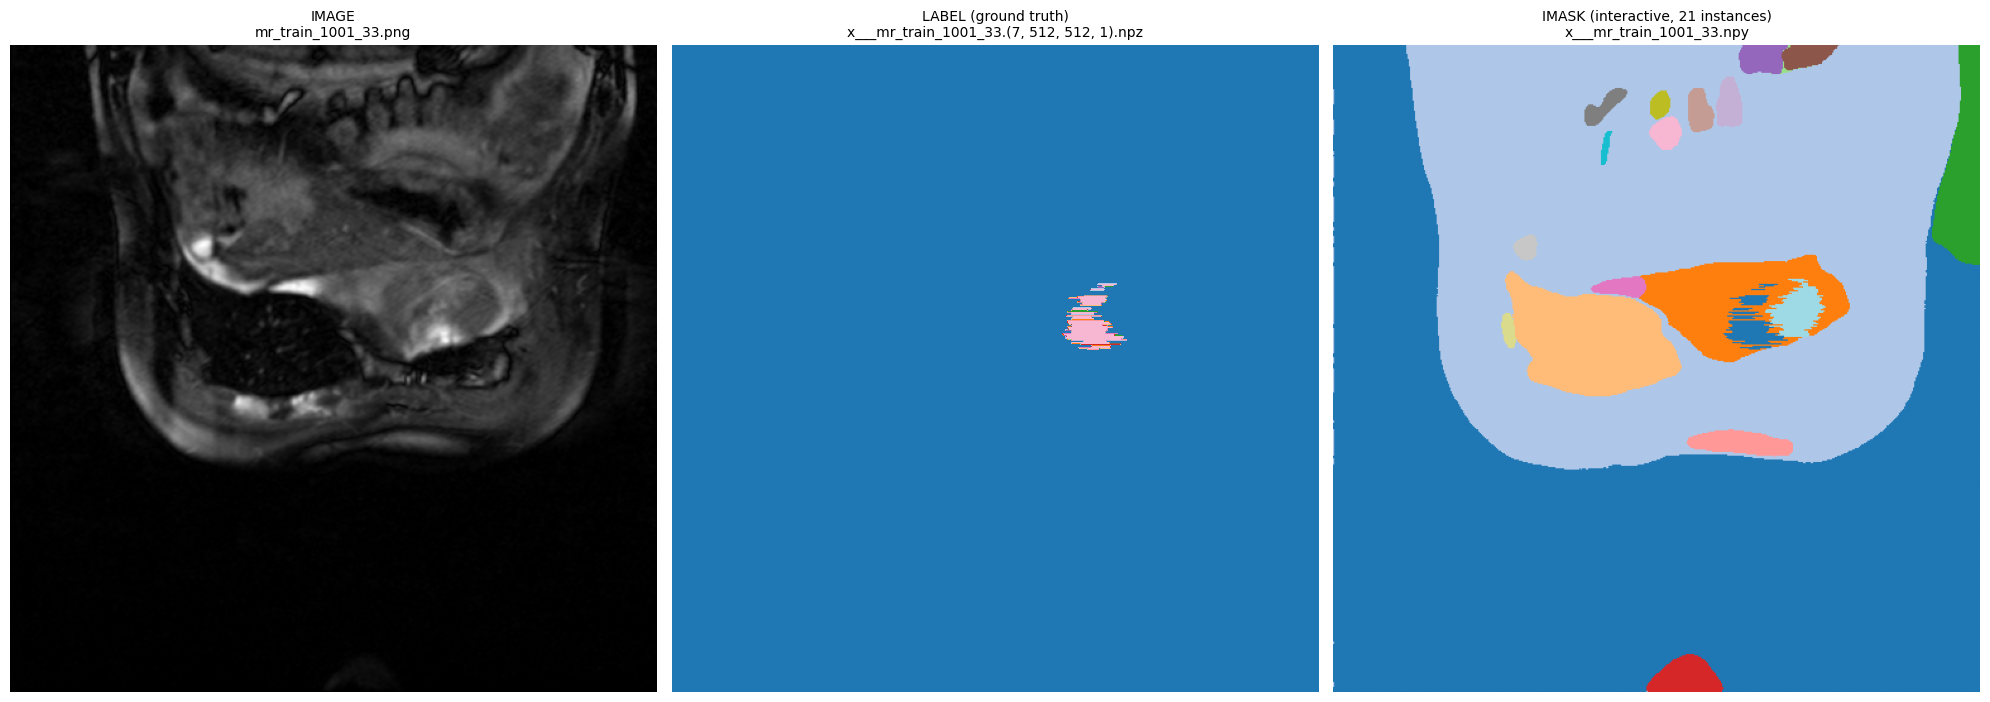

In [30]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import sparse
from PIL import Image


def find_file_by_case_prefix(folder, case_identifier):
    matching_filepaths = sorted(folder.glob(f"{case_identifier}.*"))
    if not matching_filepaths:
        raise FileNotFoundError(f'No file starting with "{case_identifier}." found in {folder}')
    if len(matching_filepaths) > 1:
        raise ValueError(f'Multiple files match "{case_identifier}." in {folder}: {matching_filepaths}')
    return matching_filepaths[0]


def find_image_file(image_folder, case_identifier):
    if "___" in case_identifier:
        path_segment, bare_case_identifier = case_identifier.split("___", maxsplit=1)
        candidate_folder = image_folder / path_segment
        if candidate_folder.is_dir():
            return find_file_by_case_prefix(candidate_folder, bare_case_identifier)
    return find_file_by_case_prefix(image_folder, case_identifier)


def squeeze_trailing_singleton_dimension(array):
    while array.ndim > 2 and array.shape[-1] == 1:
        array = array.squeeze(axis=-1)
    return array


def load_image_panel(dataset_directory, case_identifier):
    image_filepath = find_image_file(dataset_directory / "image", case_identifier)
    return np.array(Image.open(image_filepath)), image_filepath.name


def load_label_panel(dataset_directory, case_identifier):
    label_filepath = find_file_by_case_prefix(dataset_directory / "label", case_identifier)

    shape_string = label_filepath.name.split(".")[-2]
    one_hot_shape = ast.literal_eval(shape_string)

    sparse_matrix = sparse.load_npz(label_filepath)
    one_hot_array = sparse_matrix.toarray().reshape(one_hot_shape)

    number_of_label_channels = one_hot_array.shape[0]
    squeezed_array = one_hot_array.squeeze(axis=-1) if one_hot_array.shape[-1] == 1 else one_hot_array

    if number_of_label_channels == 1:
        class_index_map = squeezed_array[0]
        color_map_name = "gray"
        color_scale_max = 1
    else:
        class_index_map = squeezed_array.argmax(axis=0)
        color_map_name = "tab20"
        color_scale_max = number_of_label_channels - 1

    return class_index_map, color_map_name, color_scale_max, label_filepath.name


def load_imask_panel(dataset_directory, case_identifier):
    imask_filepath = find_file_by_case_prefix(dataset_directory / "imask", case_identifier)

    instance_id_array = squeeze_trailing_singleton_dimension(np.load(imask_filepath))
    positive_instance_ids = np.unique(instance_id_array[instance_id_array != -1])

    colormap = plt.colormaps.get_cmap("tab20")
    colored_instance_map = np.zeros((*instance_id_array.shape, 3), dtype=np.float32)
    for color_index, instance_id in enumerate(positive_instance_ids):
        colored_instance_map[instance_id_array == instance_id] = colormap(color_index % 20)[:3]

    return colored_instance_map, len(positive_instance_ids), imask_filepath.name


def visualize_image_label_imask_triplet(dataset_folder_name, case_identifier):
    dataset_directory = Path("data") / dataset_folder_name

    real_image_array, image_filename = load_image_panel(dataset_directory, case_identifier)
    label_class_index_map, label_color_map_name, label_color_scale_max, label_filename = load_label_panel(dataset_directory, case_identifier)
    colored_instance_map, instance_count, imask_filename = load_imask_panel(dataset_directory, case_identifier)

    figure, (image_axes, label_axes, imask_axes) = plt.subplots(1, 3, figsize=(20, 7))

    image_axes.imshow(real_image_array)
    image_axes.set_title(f"IMAGE\n{image_filename}", fontsize=10)
    image_axes.axis("off")

    label_axes.imshow(label_class_index_map, cmap=label_color_map_name, vmin=0, vmax=label_color_scale_max)
    label_axes.set_title(f"LABEL (ground truth)\n{label_filename}", fontsize=10)
    label_axes.axis("off")

    imask_axes.imshow(colored_instance_map)
    imask_axes.set_title(f"IMASK (interactive, {instance_count} instances)\n{imask_filename}", fontsize=10)
    imask_axes.axis("off")

    plt.tight_layout()
    plt.show()


visualize_image_label_imask_triplet(dataset_folder_name="MMWHS_MR", case_identifier="x___mr_train_1001_33")